In [1]:
import pandas as pd

# 1. SETUP: Define the name of your Excel file
# Ensure this file is in the same folder as your notebook
file_path = "2026-02-13 2025 BMO Figure spreadsheet data (grouped).xlsx"

# 2. LOAD MAIN DATA
# Note: The sheet name "Data for charts - Amanda edits " has a trailing space.
try:
    df_main = pd.read_excel(file_path, sheet_name="Data for charts - Amanda edits ")
    print("Main Data Info:")
    print(df_main.info())
    print(df_main.head())
except Exception as e:
    print(f"Error loading main data: {e}")

# 3. LOAD FREQUENCY DATA
# Note: header=1 means the headers are on the second row
try:
    df_freq = pd.read_excel(file_path, sheet_name="Frequency", header=1)
    print("\nFrequency Data Info:")
    print(df_freq.info())
    print(df_freq.head())
except Exception as e:
    print(f"Error loading frequency data: {e}")

# 4. LOAD ADDITIONAL CHARTS DATA
# Note: header=2 means the headers are on the third row
try:
    df_additional = pd.read_excel(file_path, sheet_name="Additional charts", header=2)
    print("\nAdditional Charts Data Info:")
    print(df_additional.info())
    print(df_additional.head())
except Exception as e:
    print(f"Error loading additional charts data: {e}")

Main Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   NCTId                     620 non-null    str  
 1   CT phase (grouped)        620 non-null    str  
 2   therapeutic class         620 non-null    str  
 3   use                       620 non-null    str  
 4   type                      620 non-null    str  
 5   CADRO                     588 non-null    str  
 6   biomarker name            620 non-null    str  
 7   biomarker name (grouped)  620 non-null    str  
 8   only biomarker name       604 non-null    str  
 9   measure                   440 non-null    str  
 10  measure filter            440 non-null    str  
dtypes: str(11)
memory usage: 101.1 KB
None
         NCTId CT phase (grouped) therapeutic class                use  \
0  NCT01767311         ['PHASE2']               DTT  Secondary Outcome   
1  NCT017

In [2]:
import pandas as pd

# Data Cleaning
df = df_main.copy()

# Clean up 'CT phase (grouped)'
def clean_phase(phase_str):
    if pd.isna(phase_str): return "Unknown"
    if "PHASE1" in phase_str: return "Phase 1"
    if "PHASE2" in phase_str: return "Phase 2"
    if "PHASE3" in phase_str: return "Phase 3"
    return "Other"

df['Phase'] = df['CT phase (grouped)'].apply(clean_phase)

# Clean up 'type'
df['Type'] = df['type'].fillna('Unknown')

# Clean up 'use'
def clean_use(use_str):
    if pd.isna(use_str): return "Other"
    use_str = use_str.lower()
    if "inclusion" in use_str: return "Inclusion Criteria"
    if "primary" in use_str: return "Primary Outcome"
    if "secondary" in use_str: return "Secondary Outcome"
    return "Other Outcome"

df['Use Category'] = df['use'].apply(clean_use)

# Define the exact order you want for the rows and columns
use_order = ['Inclusion Criteria', 'Primary Outcome', 'Secondary Outcome', 'Other Outcome']
type_order = ['Imaging', 'Fluid', 'Digital']

# ==========================================
# 1. GENERATE OVERALL DATA
# ==========================================
# Overall Top 15 Biomarkers
top_biomarkers = df.groupby(['biomarker name (grouped)', 'Type'])['NCTId'].nunique().reset_index()
top_biomarkers = top_biomarkers.rename(columns={'NCTId': 'Trial Count'})
top_biomarkers = top_biomarkers.sort_values('Trial Count', ascending=False).head(15)
top_biomarkers.to_csv('viz_top_biomarkers.csv', index=False)

# Overall Usage Heatmap Data
usage_data = df.groupby(['Use Category', 'Type'])['NCTId'].nunique().unstack(fill_value=0)

# Enforce exact column order (Imaging -> Fluid -> Digital)
for col in type_order:
    if col not in usage_data.columns:
        usage_data[col] = 0
usage_data = usage_data[type_order]

# Enforce exact row order (Inclusion -> Primary -> Secondary -> Other)
usage_data = usage_data.reindex(use_order, fill_value=0)

usage_data.to_csv('viz_usage_data.csv')

# ==========================================
# 2. GENERATE PHASE-SPECIFIC DATA
# ==========================================
phases_to_plot = ['Phase 1', 'Phase 2', 'Phase 3']

for phase in phases_to_plot:
    df_phase = df[df['Phase'] == phase]
    
    # Phase-specific Heatmap
    usage_data_phase = df_phase.groupby(['Use Category', 'Type'])['NCTId'].nunique().unstack(fill_value=0)
    
    # Enforce exact column order
    for col in type_order:
        if col not in usage_data_phase.columns:
            usage_data_phase[col] = 0
    usage_data_phase = usage_data_phase[type_order]
    
    # Enforce exact row order
    usage_data_phase = usage_data_phase.reindex(use_order, fill_value=0)
    
    usage_data_phase.to_csv(f'viz_usage_data_{phase.replace(" ", "")}.csv')
    
    # Phase-specific Top Biomarkers
    top_bio_phase = df_phase.groupby(['biomarker name (grouped)', 'Type'])['NCTId'].nunique().reset_index()
    top_bio_phase = top_bio_phase.rename(columns={'NCTId': 'Trial Count'})
    top_bio_phase = top_bio_phase.sort_values('Trial Count', ascending=False).head(15)
    top_bio_phase.to_csv(f'viz_top_biomarkers_{phase.replace(" ", "")}.csv', index=False)

print("Data processing complete. Overall and phase-specific files generated with fixed axis order.")

Data processing complete. Overall and phase-specific files generated with fixed axis order.


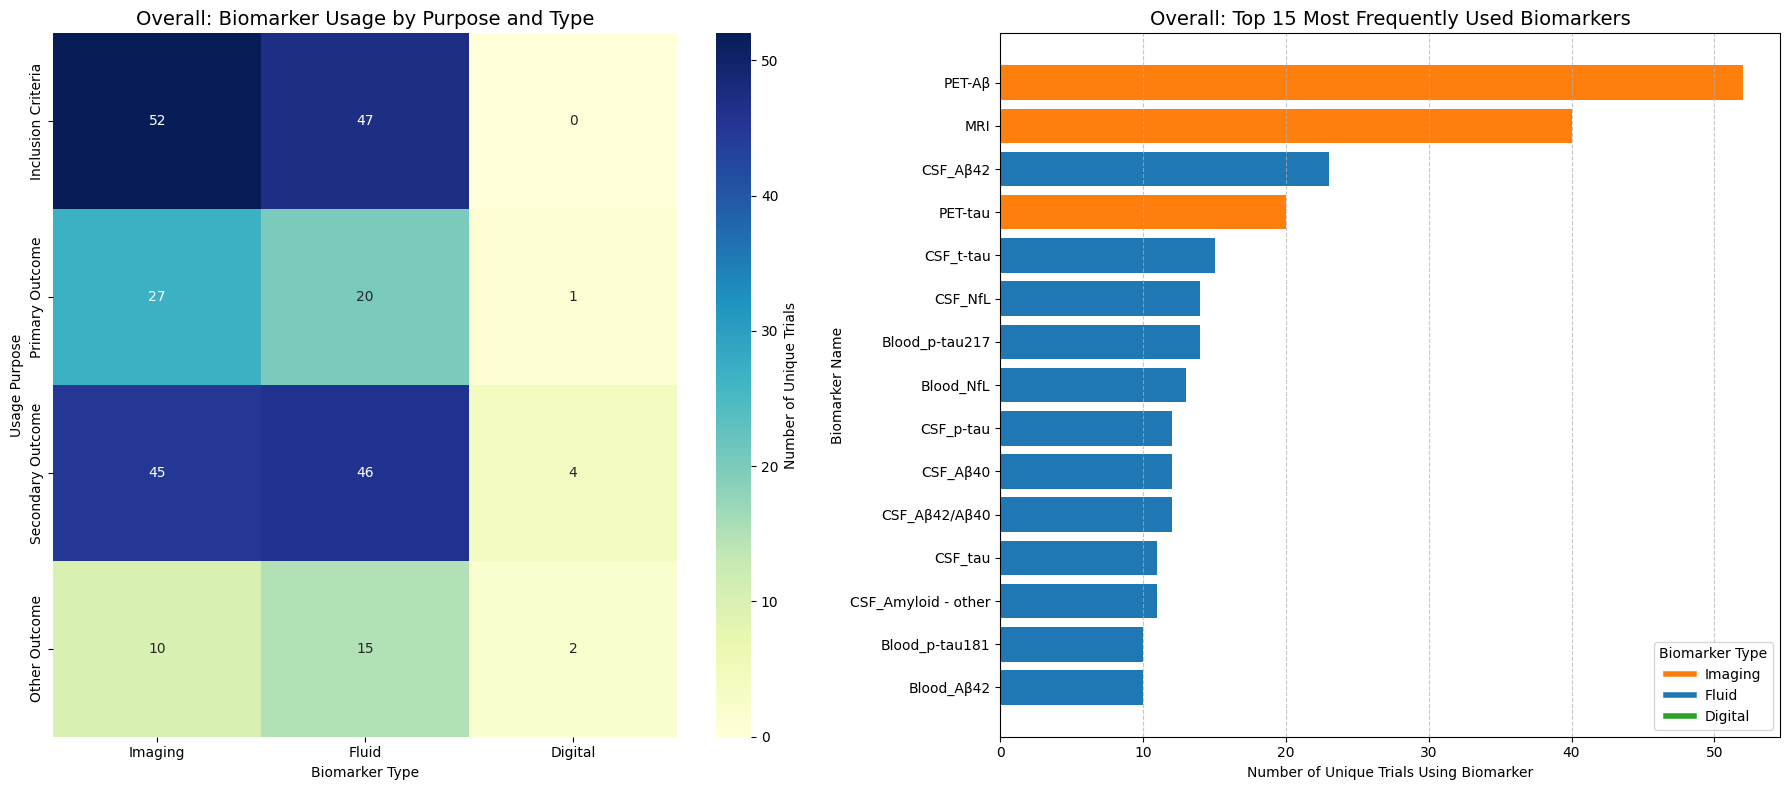

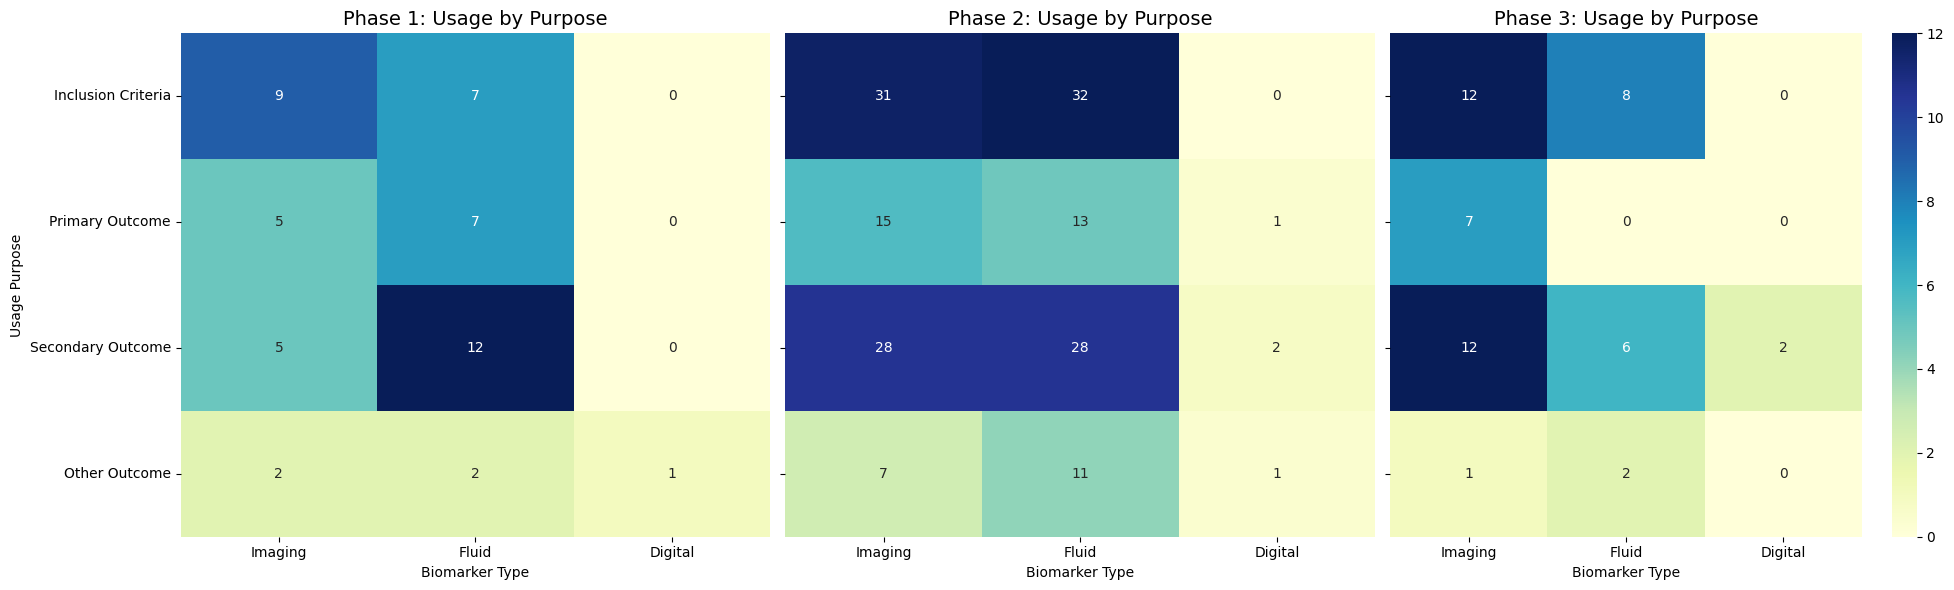

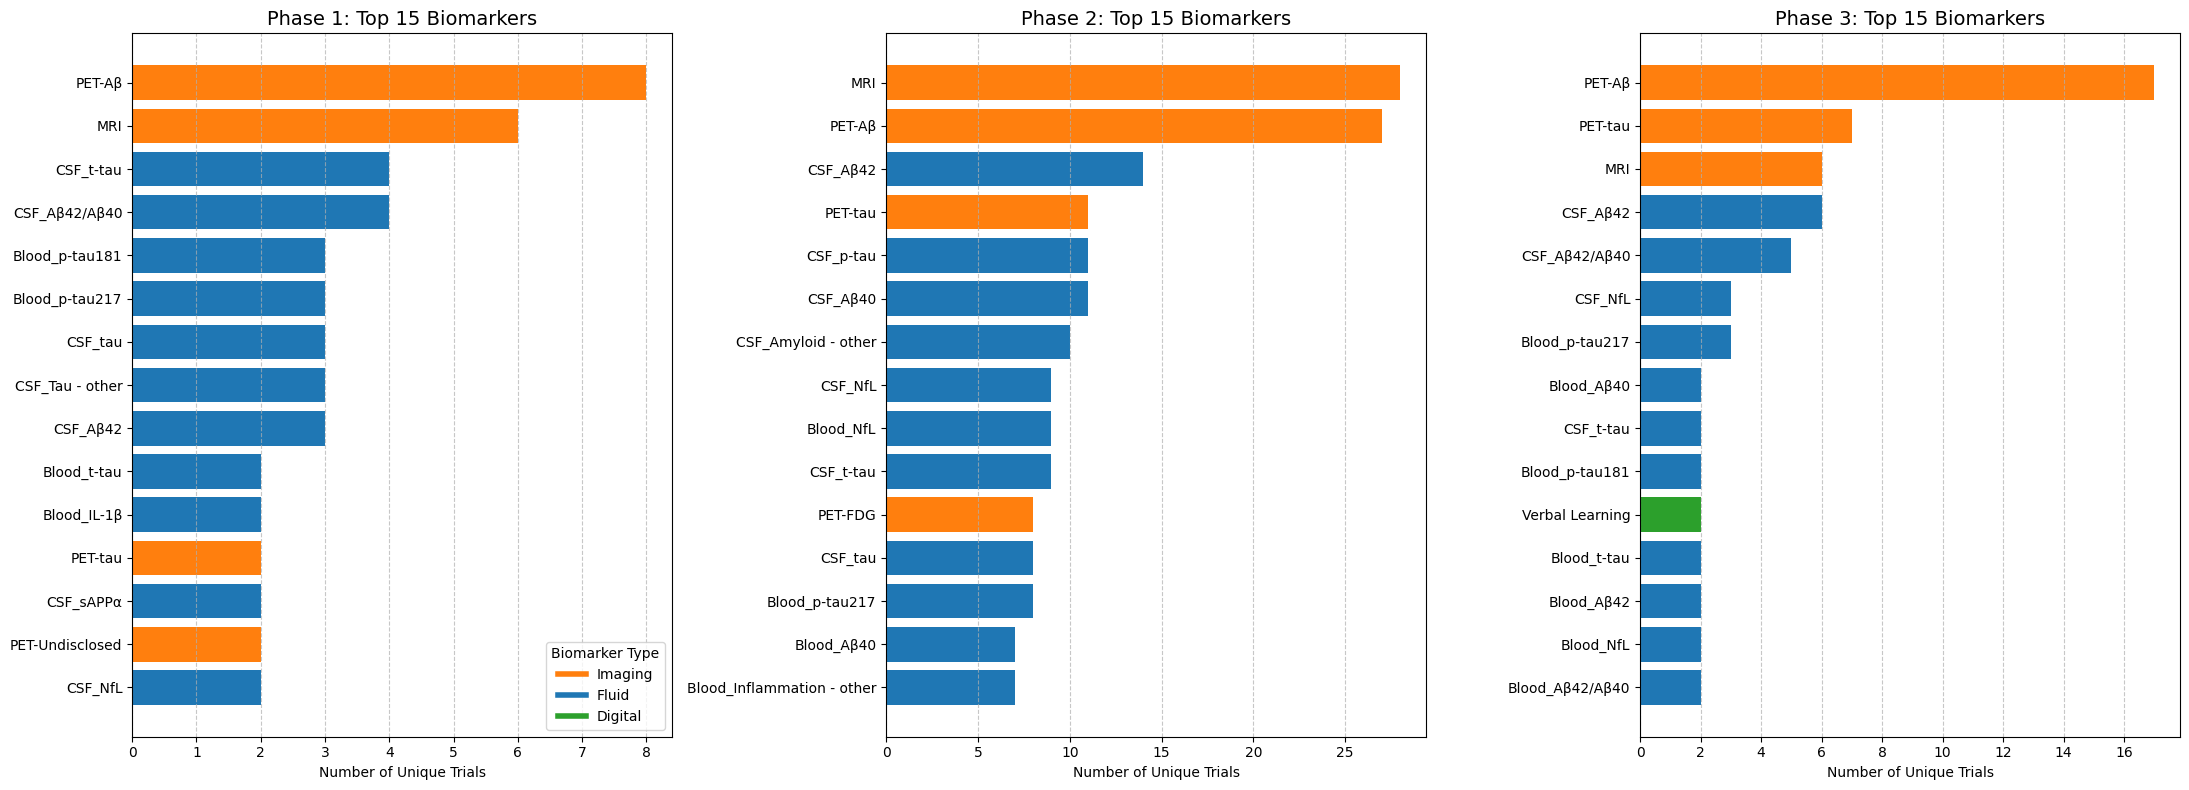

All 8 charts have been successfully displayed and saved with the new order.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Define colors
colors = {'Fluid': '#1f77b4', 'Imaging': '#ff7f0e', 'Digital': '#2ca02c'}

# Reordered custom lines to match Imaging -> Fluid -> Digital
custom_lines = [Line2D([0], [0], color=colors['Imaging'], lw=4),
                Line2D([0], [0], color=colors['Fluid'], lw=4),
                Line2D([0], [0], color=colors['Digital'], lw=4)]
legend_labels = ['Imaging', 'Fluid', 'Digital']

# ==========================================
# FIGURE 1: The Original Two Overall Charts
# ==========================================
usage_data = pd.read_csv('viz_usage_data.csv', index_col=0)
top_biomarkers = pd.read_csv('viz_top_biomarkers.csv').sort_values('Trial Count', ascending=True)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Overall Heatmap
sns.heatmap(usage_data, annot=True, fmt="d", cmap="YlGnBu", ax=ax1, cbar_kws={'label': 'Number of Unique Trials'})
ax1.set_title('Overall: Biomarker Usage by Purpose and Type', fontsize=14)
ax1.set_xlabel('Biomarker Type')
ax1.set_ylabel('Usage Purpose')

# Overall Top 15 Bar Chart
ax2.barh(top_biomarkers['biomarker name (grouped)'], top_biomarkers['Trial Count'],
         color=[colors.get(x, '#333333') for x in top_biomarkers['Type']])
ax2.set_title('Overall: Top 15 Most Frequently Used Biomarkers', fontsize=14)
ax2.set_xlabel('Number of Unique Trials Using Biomarker')
ax2.set_ylabel('Biomarker Name')
ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax2.legend(custom_lines, legend_labels, title='Biomarker Type', loc='lower right')

plt.tight_layout()
plt.savefig('Gemini_Graphs_Overall.png', dpi=300)
plt.show() 

# ==========================================
# FIGURE 2: Phase-Specific Heatmaps (1x3 Grid)
# ==========================================
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
phases = ['Phase 1', 'Phase 2', 'Phase 3']

for i, phase in enumerate(phases):
    p_data = pd.read_csv(f'viz_usage_data_{phase.replace(" ", "")}.csv', index_col=0)
    sns.heatmap(p_data, annot=True, fmt="d", cmap="YlGnBu", ax=axes2[i], cbar=(i==2))
    axes2[i].set_title(f'{phase}: Usage by Purpose', fontsize=14)
    axes2[i].set_xlabel('Biomarker Type')
    if i == 0:
        axes2[i].set_ylabel('Usage Purpose')
    else:
        axes2[i].set_ylabel('')

plt.tight_layout()
plt.savefig('Gemini_Graphs_Phase_Heatmaps.png', dpi=300)
plt.show() 

# ==========================================
# FIGURE 3: Phase-Specific Top Biomarkers (1x3 Grid)
# ==========================================
fig3, axes3 = plt.subplots(1, 3, figsize=(22, 8))

for i, phase in enumerate(phases):
    p_top = pd.read_csv(f'viz_top_biomarkers_{phase.replace(" ", "")}.csv').sort_values('Trial Count', ascending=True)
    
    axes3[i].barh(p_top['biomarker name (grouped)'], p_top['Trial Count'],
                  color=[colors.get(x, '#333333') for x in p_top['Type']])
    axes3[i].set_title(f'{phase}: Top 15 Biomarkers', fontsize=14)
    axes3[i].set_xlabel('Number of Unique Trials')
    axes3[i].grid(axis='x', linestyle='--', alpha=0.7)
    if i == 0: # Add legend only to the first subplot
         axes3[i].legend(custom_lines, legend_labels, title='Biomarker Type', loc='lower right')

plt.tight_layout()
plt.savefig('Gemini_Graphs_Phase_Bars.png', dpi=300)
plt.show()

print("All 8 charts have been successfully displayed and saved with the new order.")